## EDA

In [1]:
import os
# Token de kaggle
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_50cfd9f4e502c15625d7bd91dd537fbd'

!pip install kaggle -q

# Listar archivos del dataset
!kaggle datasets files wordsforthewise/lending-club

# Descargar dataset completo
!kaggle datasets download wordsforthewise/lending-club \
-p data/lending_club --unzip -q

name                                                           size  creationDate                
-------------------------------------------------------  ----------  --------------------------  
accepted_2007_to_2018Q4.csv.gz                            392582231  2019-12-17 23:30:10.124000  
accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv  1675133810  2019-04-10 18:09:09.272000  
rejected_2007_to_2018Q4.csv.gz                            255470782  2019-12-17 23:30:04.004000  
rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv  1782281620  2019-04-10 18:09:22.367000  
Dataset URL: https://www.kaggle.com/datasets/wordsforthewise/lending-club
License(s): CC0-1.0


In [ ]:
import pandas as pd
import numpy as np

#aqui solo se cargan las columnas que pide el profesor porque luego me quedaba sin espacio
cols_necesarias = [
    # Numéricas
    'loan_amnt', 'int_rate', 'annual_inc', 'dti',
    'fico_range_high', 'emp_length',
    # Categóricas
    'purpose', 'home_ownership', 'addr_state', 'verification_status',
    # Target
    'loan_status',
    # Extras (por si acaso)
    'grade', 'sub_grade', 'term', 'installment',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'mort_acc', 'pub_rec_bankruptcies',
    'funded_amnt', 'issue_d'
]

df = pd.read_csv('data/lending_club/accepted_2007_to_2018Q4.csv.gz',
                 compression='gzip',
                 usecols=cols_necesarias,
                 low_memory=False)

print(f"  Filas:    {df.shape[0]:,}")
print(f"  Columnas: {df.shape[1]:,}")

  Filas:    2,260,701
  Columnas: 24


In [ ]:
#Mostrar las primeras y últimas filas (head(), tail())
print("\n=== PRIMERAS 5 FILAS ===")
display(df.head())

print("\n=== ÚLTIMAS 5 FILAS ===")
display(df.tail())

#Usar info() y describe() para obtener un resumen de tipos de datos
df.info(verbose=True, show_counts=True)
display(df.describe())

#Reportar la dimensión del dataset (número de filas y columnas).
print(f"Dimensión del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")

#target
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

print("Valores únicos de loan_status:")
print(df["loan_status"].value_counts())

print("\nDistribución del target (default):")
conteo = df["default"].value_counts()
porcentaje = df["default"].value_counts(normalize=True).mul(100).round(2)
display(pd.DataFrame({'Conteo': conteo, 'Porcentaje %': porcentaje}))


=== PRIMERAS 5 FILAS ===


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,addr_state,dti,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,...,PA,5.91,679.0,7.0,0.0,2765.0,29.7,13.0,1.0,0.0
1,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,...,SD,16.06,719.0,22.0,0.0,21470.0,19.2,38.0,4.0,0.0
2,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,...,IL,10.78,699.0,6.0,0.0,7869.0,56.2,18.0,5.0,0.0
3,35000.0,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,...,NJ,17.06,789.0,13.0,0.0,7802.0,11.6,17.0,1.0,0.0
4,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,...,PA,25.37,699.0,12.0,0.0,21929.0,64.5,35.0,6.0,0.0



=== ÚLTIMAS 5 FILAS ===


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,addr_state,dti,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
2260696,40000.0,40000.0,60 months,10.49,859.56,B,B3,9 years,MORTGAGE,227000.0,...,CA,12.75,709.0,5.0,0.0,8633.0,64.9,37.0,3.0,0.0
2260697,24000.0,24000.0,60 months,14.49,564.56,C,C4,6 years,RENT,110000.0,...,FL,18.30,664.0,10.0,1.0,17641.0,68.1,31.0,2.0,1.0
2260698,14000.0,14000.0,60 months,14.49,329.33,C,C4,10+ years,MORTGAGE,95000.0,...,TX,23.36,664.0,8.0,0.0,7662.0,54.0,22.0,1.0,0.0
2260699,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   loan_amnt             2260668 non-null  float64
 1   funded_amnt           2260668 non-null  float64
 2   term                  2260668 non-null  object 
 3   int_rate              2260668 non-null  float64
 4   installment           2260668 non-null  float64
 5   grade                 2260668 non-null  object 
 6   sub_grade             2260668 non-null  object 
 7   emp_length            2113761 non-null  object 
 8   home_ownership        2260668 non-null  object 
 9   annual_inc            2260664 non-null  float64
 10  verification_status   2260668 non-null  object 
 11  issue_d               2260668 non-null  object 
 12  loan_status           2260668 non-null  object 
 13  purpose               2260668 non-null  object 
 14  addr_state            2260668 non-

,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260668e+06,2.260639e+06,2.260639e+06,2.260668e+06,2.258866e+06,2.260639e+06,2.210638e+06,2.259303e+06
mean,1.504693e+04,1.504166e+04,1.309283e+01,4.458068e+02,7.799243e+04,1.882420e+01,7.025884e+02,1.161240e+01,1.975278e-01,1.665846e+04,5.033770e+01,2.416255e+01,1.555382e+00,1.281935e-01
std,9.190245e+03,9.188413e+03,4.832138e+00,2.671735e+02,1.126962e+05,1.418333e+01,3.301124e+01,5.640861e+00,5.705150e-01,2.294831e+04,2.471307e+01,1.198753e+01,1.904981e+00,3.646130e-01
min,5.000000e+02,5.000000e+02,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,6.140000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,6.790000e+02,8.000000e+00,0.000000e+00,5.950000e+03,3.150000e+01,1.500000e+01,0.000000e+00,0.000000e+00
50%,1.290000e+04,1.287500e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,6.940000e+02,1.100000e+01,0.000000e+00,1.132400e+04,5.030000e+01,2.200000e+01,1.000000e+00,0.000000e+00
75%,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,7.190000e+02,1.400000e+01,0.000000e+00,2.024600e+04,6.940000e+01,3.100000e+01,3.000000e+00,0.000000e+00
max,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,8.500000e+02,1.010000e+02,8.600000e+01,2.904836e+06,8.923000e+02,1.760000e+02,9.400000e+01,1.200000e+01


Dimensión del dataset: 2,260,701 filas x 24 columnas
Valores únicos de loan_status:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Distribución del target (default):


,Conteo,Porcentaje %
default,,
0,1992142,88.12
1,268559,11.88


## Análisis unidimensional

### Variables numéricas

,loan_amnt,int_rate,annual_inc,dti,fico_range_high
count,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260668e+06
mean,1.504693e+04,1.309283e+01,7.799243e+04,1.882420e+01,7.025884e+02
std,9.190245e+03,4.832138e+00,1.126962e+05,1.418333e+01,3.301124e+01
min,5.000000e+02,5.310000e+00,0.000000e+00,-1.000000e+00,6.140000e+02
25%,8.000000e+03,9.490000e+00,4.600000e+04,1.189000e+01,6.790000e+02
50%,1.290000e+04,1.262000e+01,6.500000e+04,1.784000e+01,6.940000e+02
75%,2.000000e+04,1.599000e+01,9.300000e+04,2.449000e+01,7.190000e+02
max,4.000000e+04,3.099000e+01,1.100000e+08,9.990000e+02,8.500000e+02


OUTLIERS POR MÉTODO IQR 

loan_amnt            | Límite inf:    -10000.00 | Límite sup:     38000.00 | Outliers:  35,215 (1.56%)
int_rate             | Límite inf:        -0.26 | Límite sup:        25.74 | Outliers:  41,099 (1.82%)
annual_inc           | Límite inf:    -24500.00 | Límite sup:    163500.00 | Outliers: 110,041 (4.87%)
dti                  | Límite inf:        -7.01 | Límite sup:        43.39 | Outliers:  21,580 (0.96%)
fico_range_high      | Límite inf:       619.00 | Límite sup:       779.00 | Outliers:  74,846 (3.31%)
emp_length           | Límite inf:       -10.00 | Límite sup:        22.00 | Outliers:       0 (0.0%)


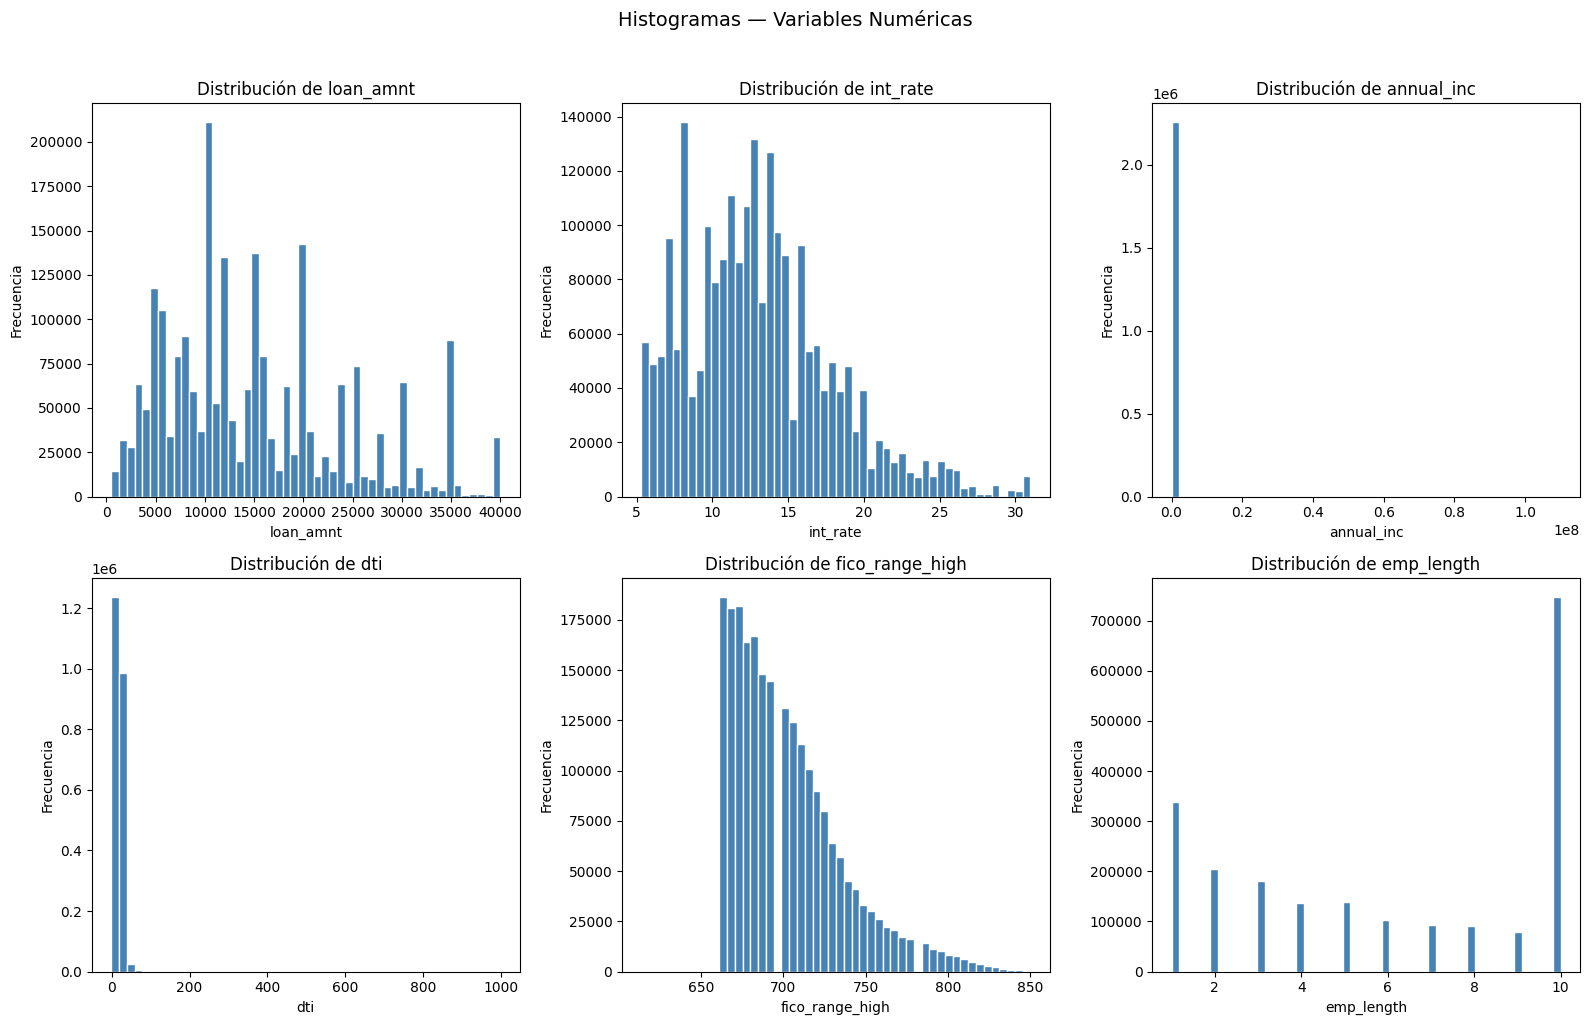

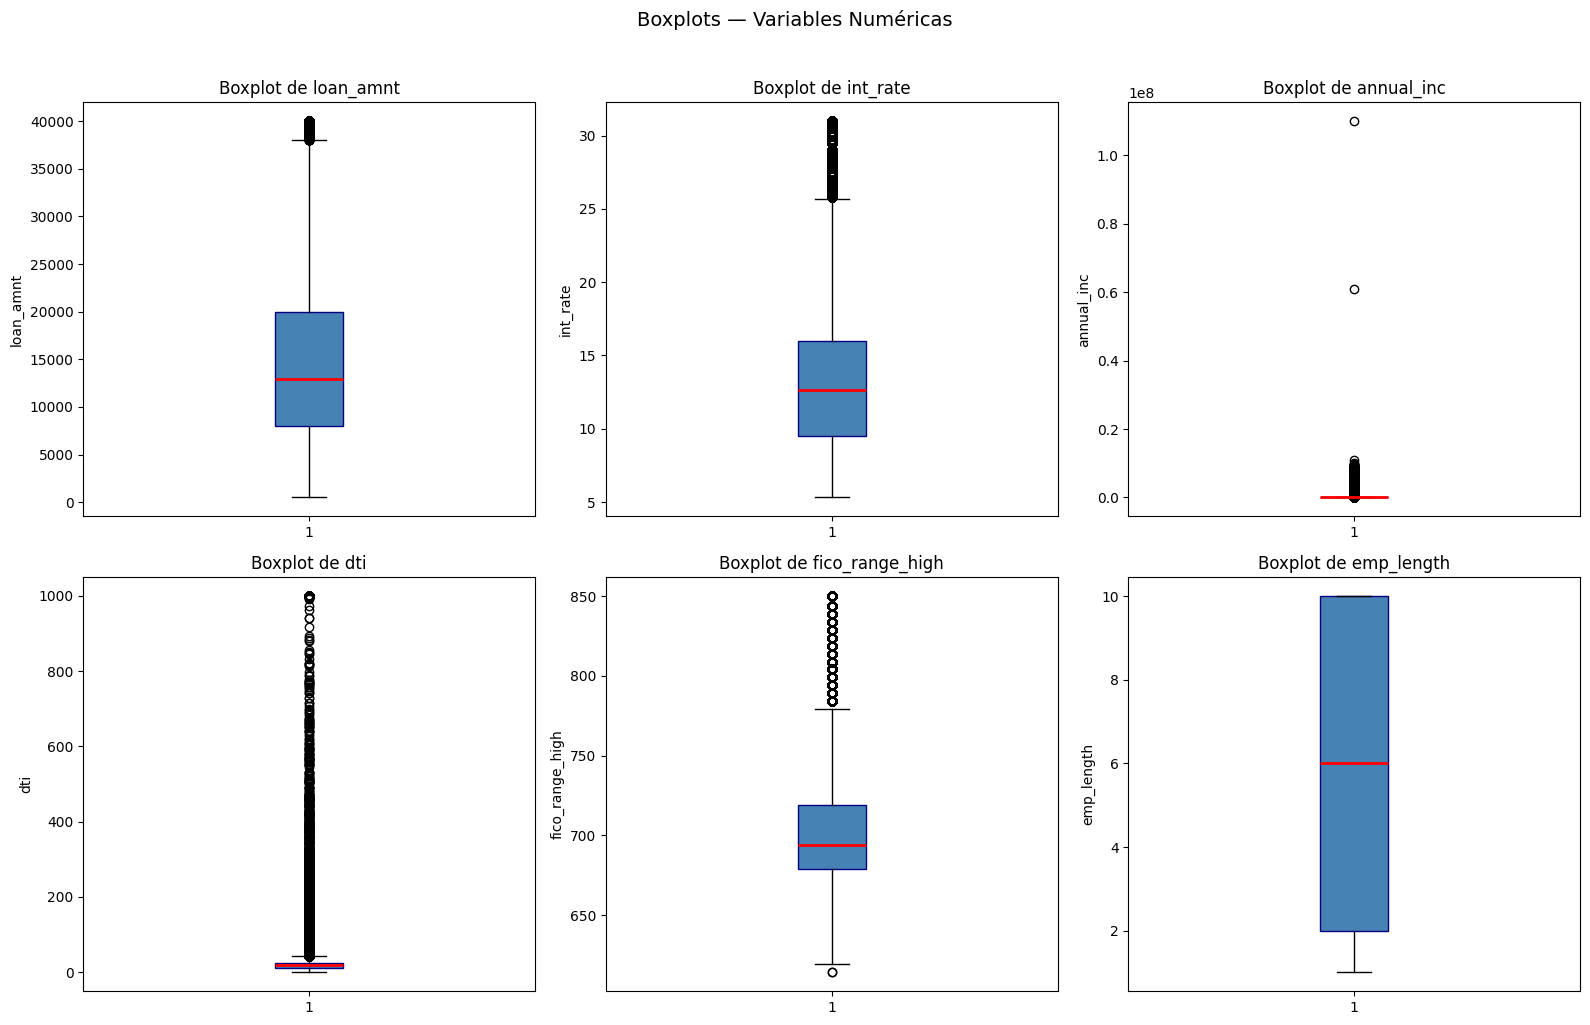

ASIMETRÍA

Variable                Asimetría            Interpretación
------------------------------------------------------------
loan_amnt                  0.7778                  Moderada
int_rate                   0.7681                  Moderada
annual_inc               493.8861                      Alta
dti                       29.2019                      Alta
fico_range_high            1.1931                      Alta
emp_length                -0.1266                    Normal


,Nulos,Porcentaje %,Tratamiento
loan_amnt,33,0.00,Sin nulos
int_rate,33,0.00,Sin nulos
annual_inc,37,0.00,Sin nulos
dti,1744,0.08,Imputar con mediana
fico_range_high,33,0.00,Sin nulos
emp_length,146940,6.50,Imputación avanzada


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

vars_numericas = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_high', 'emp_length']
display(df[vars_numericas].describe())

if df['emp_length'].dtype == object:
    df['emp_length'] = df['emp_length'].str.extract(r'(\d+)').astype(float)

#VALORES ATÍPICOS
print("OUTLIERS POR MÉTODO IQR \n")

for col in vars_numericas:
    serie = df[col].dropna()
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = serie[(serie < limite_inf) | (serie > limite_sup)]
    pct = round(len(outliers) / len(serie) * 100, 2)
    print(f"{col:20s} | Límite inf: {limite_inf:>12.2f} | Límite sup: {limite_sup:>12.2f} | Outliers: {len(outliers):>7,} ({pct}%)")

#HISTOGRAMAS
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(vars_numericas):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Histogramas — Variables Numéricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#DIAGRAMAS DE CAJA
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(vars_numericas):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'Boxplot de {col}', fontsize=12)
    axes[i].set_ylabel(col)

plt.suptitle('Boxplots — Variables Numéricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#NORMALIDAD
print("ASIMETRÍA\n")
print(f"{'Variable':20s} {'Asimetría':>12} {'Interpretación':>25}")
print("-" * 60)

for col in vars_numericas:
    skew = df[col].dropna().skew()
    if abs(skew) < 0.5:
        interp = "Normal"
    elif abs(skew) < 1:
        interp = "Moderada"
    else:
        interp = "Alta"
    print(f"{col:20s} {skew:>12.4f} {interp:>25}")
#segun los resultados de asimetria, annual_inc, dti y fico_range_high necesitan transformaciones

#TASA DE VALORES FALTANTES
nulos = df[vars_numericas].isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

tabla_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje %': pct_nulos,
    'Tratamiento': ''
})

# Aplicar umbral (> 30%)
for col in tabla_nulos.index:
    pct = tabla_nulos.loc[col, 'Porcentaje %']
    if pct > 30:
        tabla_nulos.loc[col, 'Tratamiento'] = 'Eliminación'
    elif pct > 5:
        tabla_nulos.loc[col, 'Tratamiento'] = 'Imputación avanzada'
    elif pct > 0:
        tabla_nulos.loc[col, 'Tratamiento'] = 'Imputar con mediana'
    else:
        tabla_nulos.loc[col, 'Tratamiento'] = 'Sin nulos'

display(tabla_nulos)

### Variables categóricas


  VARIABLE: PURPOSE


,Frecuencia Absoluta,Frecuencia Relativa %
purpose,,
debt_consolidation,1277877,56.53
credit_card,516971,22.87
home_improvement,150457,6.66
other,139440,6.17
major_purchase,50445,2.23
medical,27488,1.22
small_business,24689,1.09
car,24013,1.06
vacation,15525,0.69



  VARIABLE: HOME_OWNERSHIP


,Frecuencia Absoluta,Frecuencia Relativa %
home_ownership,,
MORTGAGE,1111450,49.16
RENT,894929,39.59
OWN,253057,11.19
ANY,996,0.04
OTHER,182,0.01
NONE,54,0.00



  VARIABLE: ADDR_STATE


,Frecuencia Absoluta,Frecuencia Relativa %
addr_state,,
CA,314533,13.91
NY,186389,8.24
TX,186335,8.24
FL,161991,7.17
IL,91173,4.03
NJ,83132,3.68
PA,76939,3.40
OH,75132,3.32
GA,74196,3.28



  VARIABLE: VERIFICATION_STATUS


,Frecuencia Absoluta,Frecuencia Relativa %
verification_status,,
Source Verified,886231,39.20
Not Verified,744806,32.95
Verified,629631,27.85


CATEGORÍAS CON FRECUENCIA BAJA


purpose:
  'vacation': 0.69%
  'moving': 0.68%
  'house': 0.63%
  'wedding': 0.1%
  'renewable_energy': 0.06%
  'educational': 0.02%

home_ownership:
  'ANY': 0.04%
  'OTHER': 0.01%
  'NONE': 0.0%

addr_state:
  'KY': 0.97%
  'OK': 0.92%
  'KS': 0.85%
  'AR': 0.76%
  'UT': 0.66%
  'MS': 0.56%
  'NM': 0.53%
  'NH': 0.49%
  'HI': 0.47%
  'RI': 0.44%
  'WV': 0.37%
  'NE': 0.35%
  'DE': 0.29%
  'MT': 0.28%
  'DC': 0.24%
  'AK': 0.23%
  'ME': 0.22%
  'VT': 0.22%
  'WY': 0.21%
  'SD': 0.2%
  'ID': 0.19%
  'ND': 0.16%
  'IA': 0.0%

verification_status: No hay categorías con frecuencia < 1%


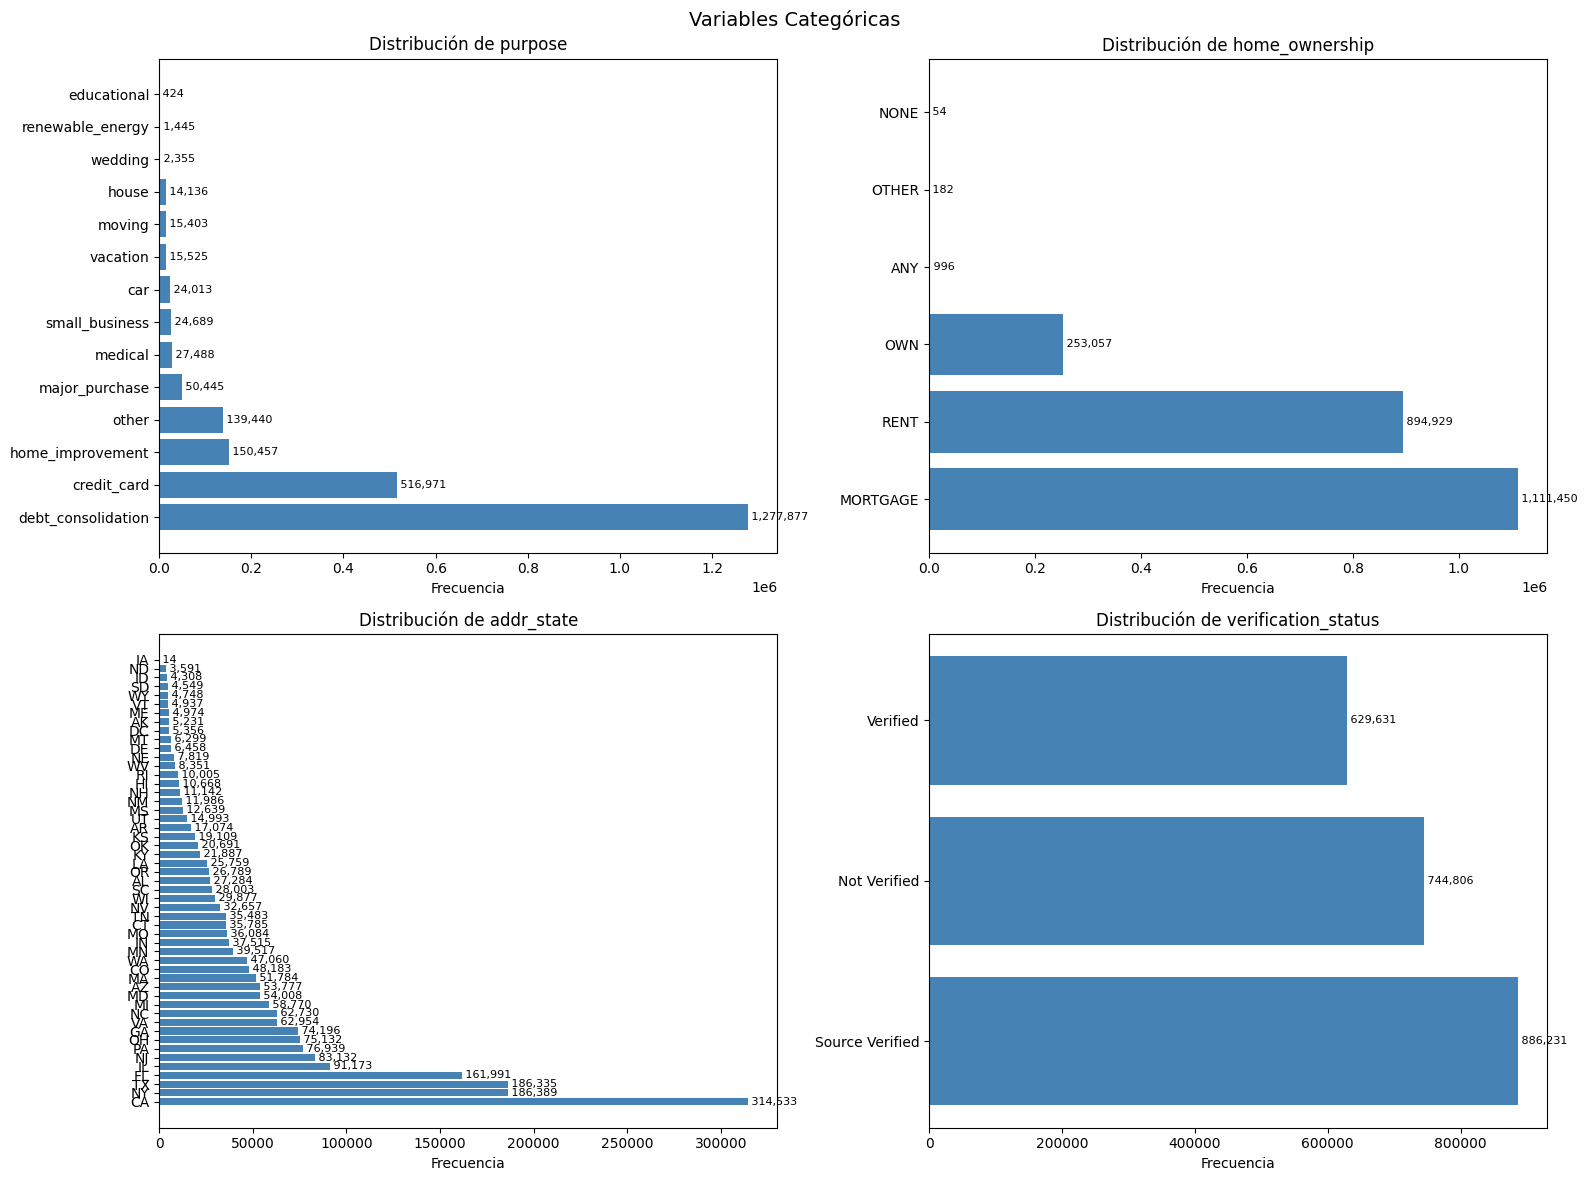

VALORES FALTANTES — VARIABLES CATEGÓRICAS

purpose                   | Nulos:      33 |   0.0% | Sin nulos
home_ownership            | Nulos:      33 |   0.0% | Sin nulos
addr_state                | Nulos:      33 |   0.0% | Sin nulos
verification_status       | Nulos:      33 |   0.0% | Sin nulos


In [ ]:
#Frecuencia absoluta y relativa
vars_categoricas = ['purpose', 'home_ownership', 'addr_state', 'verification_status']

for col in vars_categoricas:
    print(f"\n{'='*55}")
    print(f"  VARIABLE: {col.upper()}")
    print(f"{'='*55}")

    freq_abs = df[col].value_counts()
    freq_rel = df[col].value_counts(normalize=True).mul(100).round(2)

    tabla = pd.DataFrame({
        'Frecuencia Absoluta': freq_abs,
        'Frecuencia Relativa %': freq_rel
    })
    display(tabla)

#Identificar categorías con muy baja frecuencia que podrían agruparse en una categoría “Otros”. (<1%)
print("CATEGORÍAS CON FRECUENCIA BAJA\n")

for col in vars_categoricas:
    freq_rel = df[col].value_counts(normalize=True).mul(100).round(2)
    raras = freq_rel[freq_rel < 1]
    if len(raras) > 0:
        print(f"\n{col}:")
        for cat, pct in raras.items():
            print(f"  '{cat}': {pct}%")
    else:
        print(f"\n{col}: No hay categorías con frecuencia < 1%")

#Generar gráficos de barras horizontales o verticales para visualizar la distribución.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(vars_categoricas):
    freq = df[col].value_counts()
    axes[i].barh(freq.index, freq.values, color='steelblue')
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('Frecuencia')
    for j, v in enumerate(freq.values):
        axes[i].text(v, j, f' {v:,}', va='center', fontsize=8)

plt.suptitle('Variables Categóricas', fontsize=14)
plt.tight_layout()
plt.show()

#Detectar si existen categorías con significado redundante o que puedan unificarse.

#Calcular la tasa de valores faltantes y considerar su tratamiento (moda, categoría “Desconocido”, o eliminación si es muy alta).
print("VALORES FALTANTES — VARIABLES CATEGÓRICAS\n")

for col in vars_categoricas:
    nulos = df[col].isnull().sum()
    pct = round(nulos / len(df) * 100, 2)

    if pct > 30:
        decision = 'Eliminar columna'
    elif pct > 5:
        decision = 'Imputar con categoría Desconocido'
    elif pct > 0:
        decision = 'Imputar con moda'
    else:
        decision = 'Sin nulos'

    print(f"{col:25s} | Nulos: {nulos:>7,} | {pct:>5}% | {decision}")

### Variable objetivo

   DISTRIBUCIÓN DE LA VARIABLE OBJETIVO — default
            Clase   Conteo  Porcentaje (%)
Fully Paid      0  1076751           80.04
Charged Off     1   268559           19.96
   Total de registros válidos: 1,345,310
   Desbalance (mayoría/minoría): 4.01:1


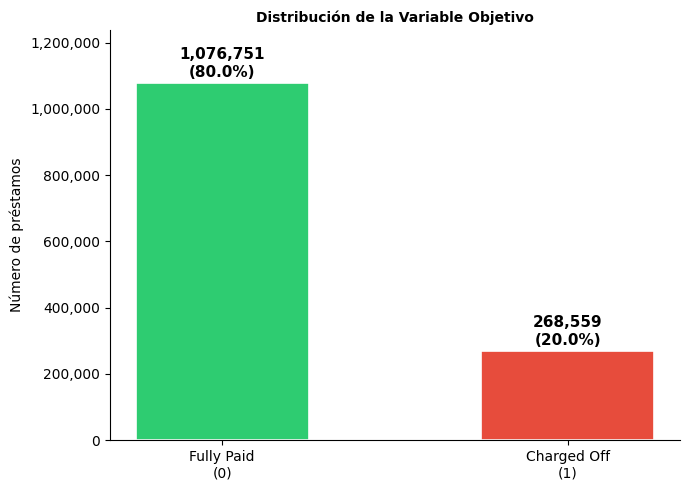

In [ ]:
#Calcular la distribución de clases (0 = Fully Paid, 1 = Charged Off) en valores absolutos y porcentajes.
df_eda = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df_eda['default'] = (df_eda['loan_status'] == 'Charged Off').astype(int)

conteo = df_eda['default'].value_counts().sort_index()
porcentaje = df_eda['default'].value_counts(normalize=True).sort_index() * 100

dist_target = pd.DataFrame({
    'Clase': ['0', '1'],
    'Conteo': conteo.values,
    'Porcentaje (%)': porcentaje.values.round(2)
})
dist_target.index = ['Fully Paid', 'Charged Off']

print("=" * 55)
print("   DISTRIBUCIÓN DE LA VARIABLE OBJETIVO — default")
print("=" * 55)
print(dist_target.to_string())
print("=" * 55)
print(f"   Total de registros válidos: {len(df_eda):,}")
print(f"   Desbalance (mayoría/minoría): "
      f"{conteo[0]/conteo[1]:.2f}:1")
print("=" * 55)

#Visualizar con un gráfico de barras o pastel.
PALETTE = {'Fully Paid': '#2ecc71', 'Charged Off': '#e74c3c'}

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ['Fully Paid\n(0)', 'Charged Off\n(1)'],
    conteo.values,
    color=[PALETTE['Fully Paid'], PALETTE['Charged Off']],
    edgecolor='white', linewidth=1.2, width=0.5
)
for bar, cnt, pct in zip(bars, conteo.values, porcentaje.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + conteo.max() * 0.01,
        f'{cnt:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Distribución de la Variable Objetivo',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Número de préstamos', fontsize=10)
ax.set_ylim(0, conteo.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Análisis bidimensional

### Relación numérica ↔ default

  DIFERENCIA DE MEDIAS, PRUEBA MANN-WHITNEY Y CORRELACIÓN PUNTO-BISERIAL 

Variable                Media_0    Media_1    Δ Media      p-value Significancia     r_pb
------------------------------------------------------------------------------------------
loan_amnt              14134.37   15565.06    1430.69     0.00e+00 Muy alta   0.0656
int_rate                  12.62      15.71       3.09     0.00e+00 Muy alta   0.2588
annual_inc             77705.95   70400.74   -7305.20     0.00e+00 Muy alta  -0.0418
dti                       17.81      20.17       2.36     0.00e+00 Muy alta   0.0845
fico_range_high          702.26     691.85     -10.41     0.00e+00 Muy alta  -0.1307
emp_length                 6.08       5.95      -0.13     1.98e-62 Muy alta  -0.0142


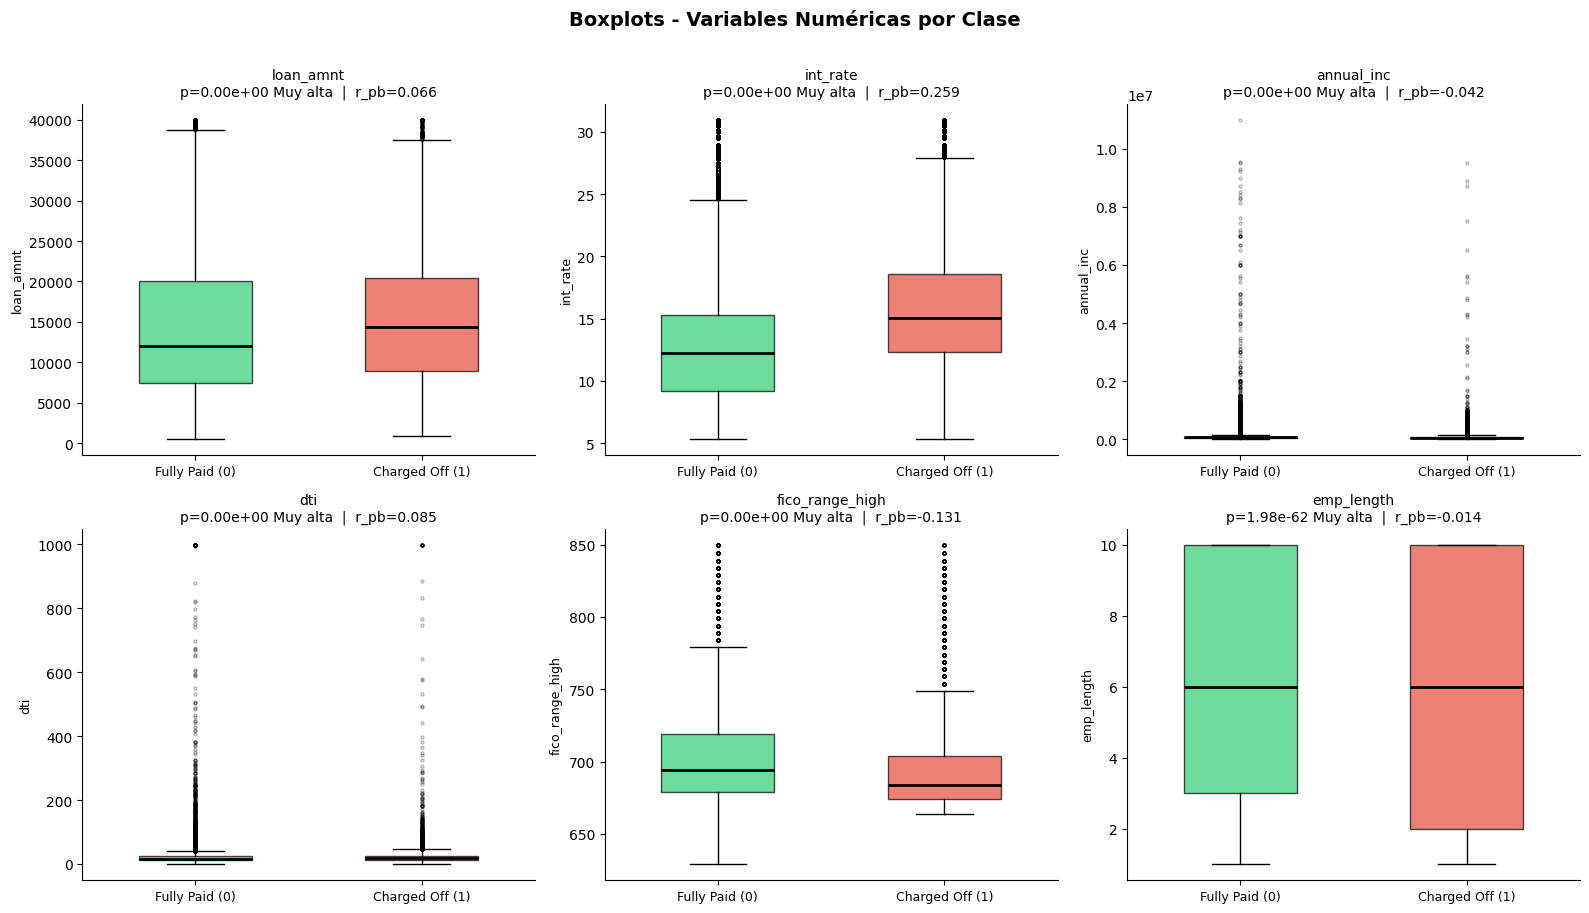

In [ ]:
#Calcular la diferencia de medias entre clases y realizar una prueba t de Student o prueba de Mann-Whitney
#Calcular la correlación punto-biserial entre cada variable numérica y la variable binaria default.
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

vars_num = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
            'fico_range_high', 'emp_length']

clase0 = df_eda[df_eda['default'] == 0]
clase1 = df_eda[df_eda['default'] == 1]

print("  DIFERENCIA DE MEDIAS, PRUEBA MANN-WHITNEY Y CORRELACIÓN PUNTO-BISERIAL \n")

print(f"{'Variable':<20} {'Media_0':>10} {'Media_1':>10} {'Δ Media':>10} "
      f"{'p-value':>12} {'Significancia':>6} {'r_pb':>8}")
print("-" * 90)

resultados = {}
for var in vars_num:
    s0 = clase0[var].dropna()
    s1 = clase1[var].dropna()

    media0 = s0.mean()
    media1 = s1.mean()
    delta  = media1 - media0

    # Mann-Whitney
    stat, pval = stats.mannwhitneyu(s0, s1, alternative='two-sided')

    # Correlación punto-biserial
    serie_var  = df_eda[var].dropna()
    serie_def  = df_eda.loc[serie_var.index, 'default']
    rpb, _     = stats.pointbiserialr(serie_def, serie_var)

    sig = 'Muy alta' if pval < 0.001 else ('Alta' if pval < 0.01 else
          ('Regular'  if pval < 0.05  else 'NS'))

    resultados[var] = dict(media0=media0, media1=media1,
                           delta=delta, pval=pval, sig=sig, rpb=rpb)

    print(f"{var:<20} {media0:>10.2f} {media1:>10.2f} {delta:>10.2f} "
          f"{pval:>12.2e} {sig:>6} {rpb:>8.4f}")

#Generar boxplots comparativos por clase (default = 0 vs 1) para cada variable numérica
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
PALETTE = {0: '#2ecc71', 1: '#e74c3c'}
LABELS  = {0: 'Fully Paid (0)', 1: 'Charged Off (1)'}

for i, var in enumerate(vars_num):
    ax = axes[i]
    data_plot = [clase0[var].dropna(), clase1[var].dropna()]

    bp = ax.boxplot(data_plot, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=2,
                                   alpha=0.3, linestyle='none'))

    for patch, color in zip(bp['boxes'], PALETTE.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    r   = resultados[var]
    sig = r['sig']
    ax.set_title(f"{var}\np={r['pval']:.2e} {sig}  |  r_pb={r['rpb']:.3f}",
                 fontsize=10)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Fully Paid (0)', 'Charged Off (1)'], fontsize=9)
    ax.set_ylabel(var, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Boxplots - Variables Numéricas por Clase',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Relación categórica ↔ default

  PRUEBA CHI-CUADRADO: VARIABLES CATEGÓRICAS vs DEFAULT 

Variable                       Chi2      p-value Significancia   V Cramer
-----------------------------------------------------------------
purpose                     4144.20     0.00e+00 Muy Alta     0.0555
home_ownership              6743.19     0.00e+00 Muy Alta     0.0708
addr_state                  3403.58     0.00e+00 Muy Alta     0.0503
verification_status        11387.44     0.00e+00 Muy Alta     0.0920

 TABLAS DE CONTINGENCIA 

 
  PURPOSE
  Chi2=4144.20  p=0.00e+00  Muy Alta  V=0.0555
─────────────────────────────────────────────────────────────────
                    Fully Paid (0)  Charged Off (1)   Total  Tasa Default (%)
purpose                                                                      
small_business               10836             4580   15416             29.71
renewable_energy               712              221     933             23.69
moving                        7266             2214    9480   

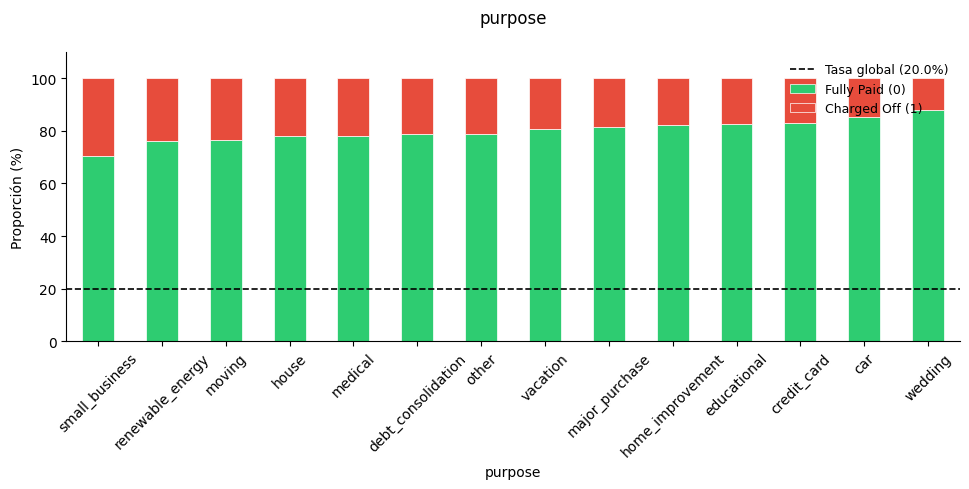

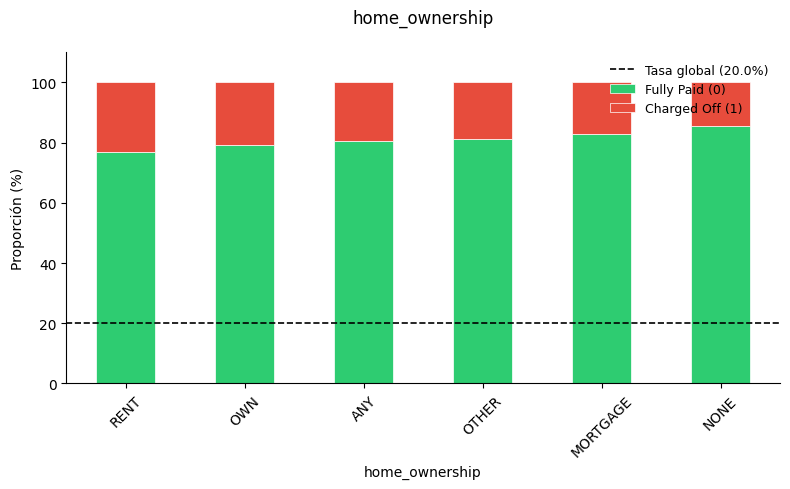

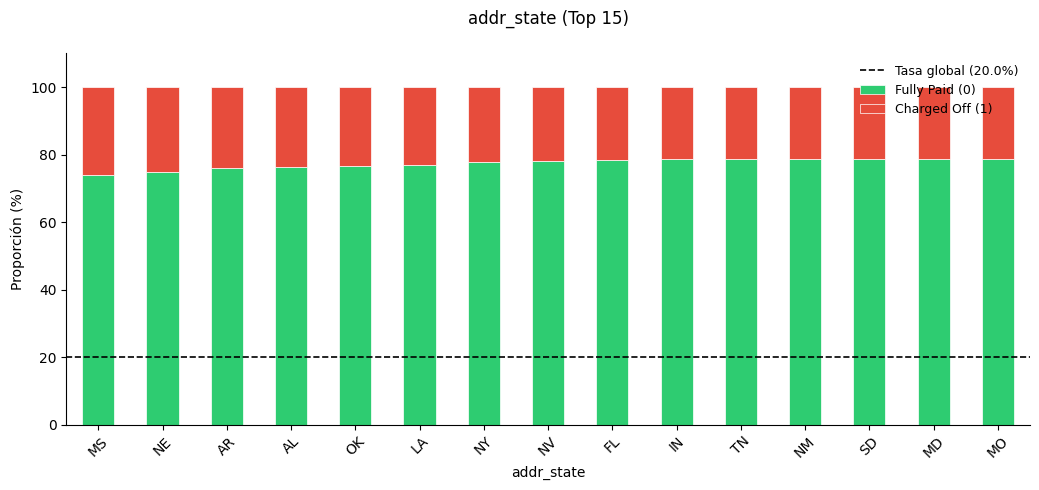

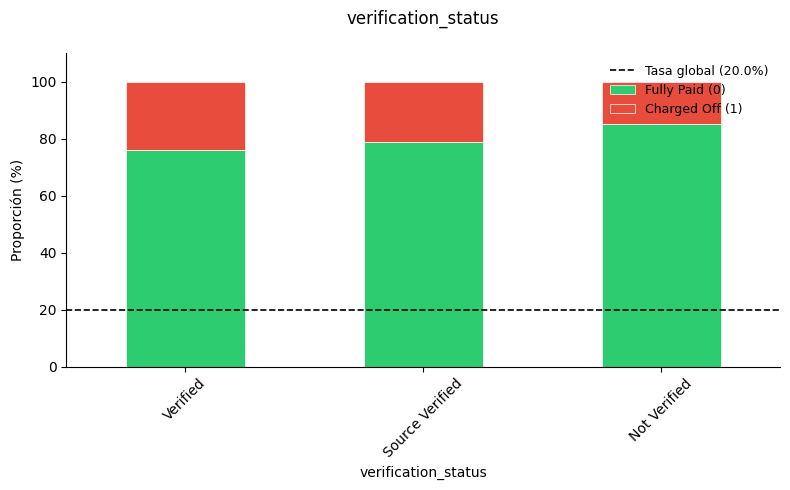

In [ ]:
from scipy.stats import chi2_contingency
vars_cat = ['purpose', 'home_ownership', 'addr_state', 'verification_status']

#PRUEBA DE CHI-CUADRADO
print("  PRUEBA CHI-CUADRADO: VARIABLES CATEGÓRICAS vs DEFAULT \n")
print(f"{'Variable':<22} {'Chi2':>12} {'p-value':>12} {'Significancia':>6} {'V Cramer':>10}")
print("-" * 65)

resultados_cat = {}
for var in vars_cat:
    tabla = pd.crosstab(df_eda[var], df_eda['default'])
    chi2, pval, dof, _ = chi2_contingency(tabla)

    # V de Cramer (magnitud del efecto)
    n = tabla.values.sum()
    k = min(tabla.shape) - 1
    v_cramer = np.sqrt(chi2 / (n * k))

    sig = 'Muy Alta' if pval < 0.001 else ('Alta' if pval < 0.01 else
          ('Regular'  if pval < 0.05  else 'NS'))

    resultados_cat[var] = dict(chi2=chi2, pval=pval, sig=sig,
                                v_cramer=v_cramer, tabla=tabla)

    print(f"{var:<22} {chi2:>12.2f} {pval:>12.2e} {sig:>6} {v_cramer:>10.4f}")

#TABLAS DE CONTINGENCIA
print("\n TABLAS DE CONTINGENCIA \n")
for var in vars_cat:
    tabla = resultados_cat[var]['tabla'].copy()
    tabla.columns = ['Fully Paid (0)', 'Charged Off (1)']
    tabla['Total']          = tabla.sum(axis=1)
    tabla['Tasa Default (%)'] = (tabla['Charged Off (1)'] /
                                  tabla['Total'] * 100).round(2)
    tabla = tabla.sort_values('Tasa Default (%)', ascending=False)

    print(f" \n  {var.upper()}")
    print(f"  Chi2={resultados_cat[var]['chi2']:.2f}  "
          f"p={resultados_cat[var]['pval']:.2e}  "
          f"{resultados_cat[var]['sig']}  "
          f"V={resultados_cat[var]['v_cramer']:.4f}")
    print(f"{'─'*65}")
    print(tabla.to_string())

#GRÁFICOS DE BARRAS APILADAS
for var in vars_cat:
    tabla = resultados_cat[var]['tabla'].copy()
    tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
    tabla_pct.columns = ['Fully Paid (0)', 'Charged Off (1)']
    tabla_pct = tabla_pct.sort_values('Charged Off (1)', ascending=False)

    if len(tabla_pct) > 15:
        tabla_pct = tabla_pct.head(15)
        titulo_extra = ' (Top 15)'
    else:
        titulo_extra = ''

    fig, ax = plt.subplots(figsize=(max(8, len(tabla_pct) * 0.7), 5))

    tabla_pct[['Fully Paid (0)', 'Charged Off (1)']].plot(
        kind='bar', stacked=True, ax=ax,
        color=['#2ecc71', '#e74c3c'],
        edgecolor='white', linewidth=0.5
    )

    tasa_global = df_eda['default'].mean() * 100
    ax.axhline(tasa_global, color='black', linestyle='--',
               linewidth=1.2, label=f'Tasa global ({tasa_global:.1f}%)')

    ax.set_title(
        f'{var}{titulo_extra}\n'
    )

    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Proporción (%)', fontsize=10)
    ax.set_ylim(0, 110)
    ax.legend(loc='upper right', fontsize=9, frameon=False)
    ax.tick_params(axis='x', rotation=45)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

### Multicolinealidad

  MATRIZ DE CORRELACIÓN DE PEARSON — VARIABLES NUMÉRICAS 

                 loan_amnt  int_rate  annual_inc     dti  fico_range_high  emp_length
loan_amnt           1.0000    0.1417      0.3118  0.0321           0.1010      0.0904
int_rate            0.1417    1.0000     -0.0722  0.1469          -0.4054     -0.0045
annual_inc          0.3118   -0.0722      1.0000 -0.1405           0.0710      0.0663
dti                 0.0321    0.1469     -0.1405  1.0000          -0.0619      0.0268
fico_range_high     0.1010   -0.4054      0.0710 -0.0619           1.0000      0.0193
emp_length          0.0904   -0.0045      0.0663  0.0268           0.0193      1.0000


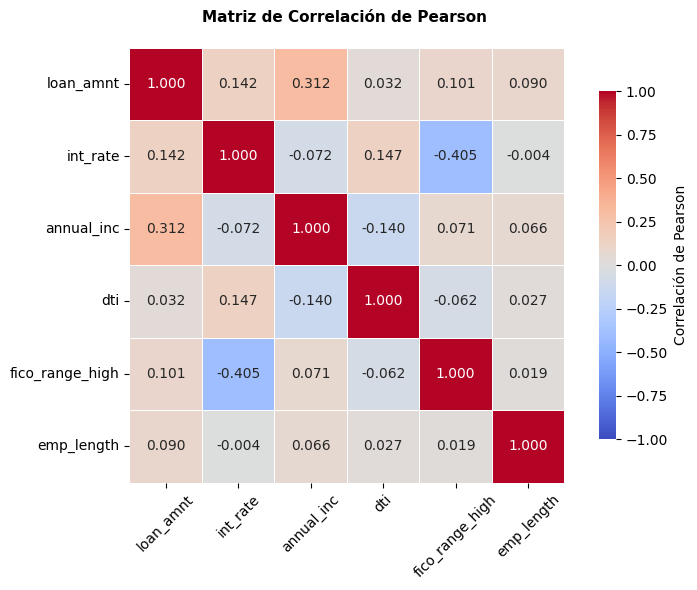

  MATRIZ V DE CRAMER — VARIABLES CATEGÓRICAS 

                     purpose  home_ownership  addr_state  verification_status
purpose               1.0000          0.0861      0.0214               0.0618
home_ownership        0.0861          1.0000      0.1113               0.0288
addr_state            0.0214          0.1113      1.0000               0.0214
verification_status   0.0618          0.0288      0.0214               1.0000

  PARES CON ASOCIACIÓN NOTABLE (V > 0.1):
  home_ownership — addr_state                  0.1113 


In [ ]:
import seaborn as sns
#CALCULAR MATRIZ DE CORRELACIONES
vars_num = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
            'fico_range_high', 'emp_length']

corr_matrix = df_eda[vars_num].corr(method='pearson')

print("  MATRIZ DE CORRELACIÓN DE PEARSON — VARIABLES NUMÉRICAS \n")
print(corr_matrix.round(4).to_string())

#HEAT MAP
fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
mask_lower = np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1)

sns.heatmap(
    corr_matrix,
    annot=True, fmt='.3f',
    cmap='coolwarm', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax,
    cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.8}
)

for i in range(len(vars_num)):
    for j in range(len(vars_num)):
        if i != j and abs(corr_matrix.iloc[i, j]) > 0.7:
            ax.add_patch(plt.Rectangle((j, i), 1, 1,
                         fill=False, edgecolor='black',
                         linewidth=2.5, zorder=3))

ax.set_title('Matriz de Correlación de Pearson \n',
             fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

#ASOCIACÓN
vars_cat = ['purpose', 'home_ownership', 'addr_state', 'verification_status']

def v_cramer(x, y):
    tabla = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.values.sum()
    k = min(tabla.shape) - 1
    return np.sqrt(chi2 / (n * k))

n_cat = len(vars_cat)
v_matrix = pd.DataFrame(np.zeros((n_cat, n_cat)),
                         index=vars_cat, columns=vars_cat)

for i, v1 in enumerate(vars_cat):
    for j, v2 in enumerate(vars_cat):
        if i == j:
            v_matrix.loc[v1, v2] = 1.0
        elif i < j:
            v = v_cramer(df_eda[v1], df_eda[v2])
            v_matrix.loc[v1, v2] = v
            v_matrix.loc[v2, v1] = v

print("  MATRIZ V DE CRAMER — VARIABLES CATEGÓRICAS \n")
print(v_matrix.round(4).to_string())

print("\n  PARES CON ASOCIACIÓN NOTABLE (V > 0.1):")
for i in range(n_cat):
    for j in range(i+1, n_cat):
        v = v_matrix.iloc[i, j]
        if v > 0.1:
            print(f"  {vars_cat[i]} — {vars_cat[j]:<25} {v:>8.4f} ")

#REDUNDANCIAS

### KDE

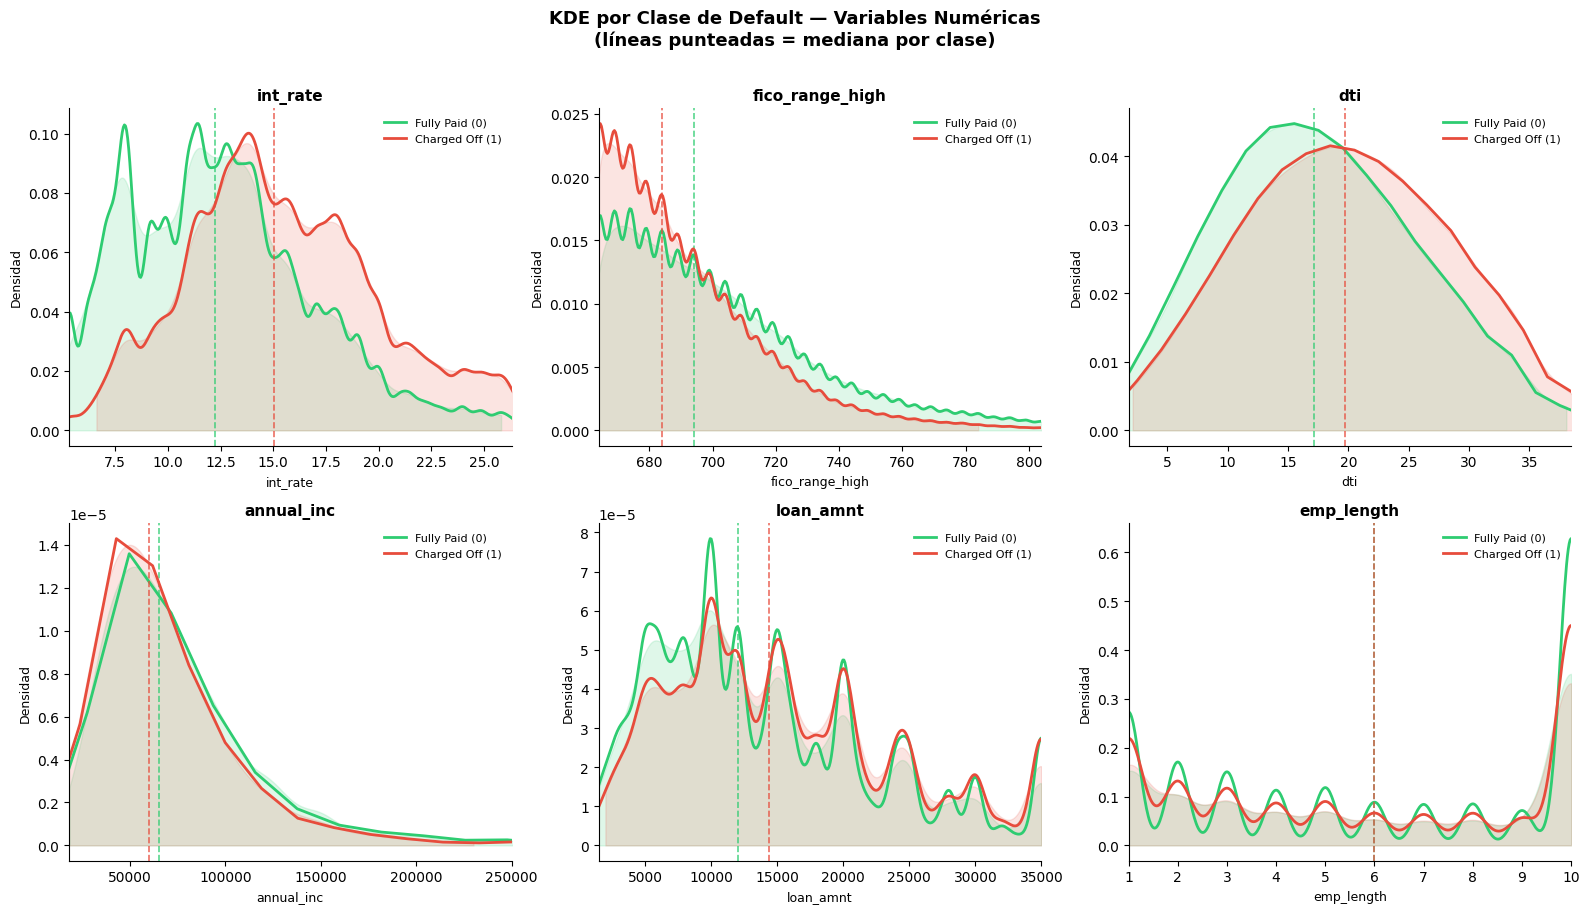

In [ ]:
#GRÁFICOS DE DENSIDAD (KDE)
vars_kde = ['int_rate', 'fico_range_high', 'dti', 'annual_inc',
            'loan_amnt', 'emp_length']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

COLORES = {0: '#2ecc71', 1: '#e74c3c'}
LABELS  = {0: 'Fully Paid (0)', 1: 'Charged Off (1)'}

for i, var in enumerate(vars_kde):
    ax = axes[i]

    for clase in [0, 1]:
        datos = df_eda[df_eda['default'] == clase][var].dropna()

        # KDE
        datos.plot.kde(ax=ax, color=COLORES[clase],
                       linewidth=2, label=LABELS[clase])

        # Área bajo la curva
        kde = stats.gaussian_kde(datos.sample(min(len(datos), 50_000),
                                              random_state=42))
        x_range = np.linspace(datos.quantile(0.01),
                              datos.quantile(0.99), 300)
        ax.fill_between(x_range, kde(x_range),
                        alpha=0.15, color=COLORES[clase])

        # Línea de mediana
        mediana = datos.median()
        ax.axvline(mediana, color=COLORES[clase],
                   linestyle='--', linewidth=1.2, alpha=0.8)

    ax.set_title(var, fontsize=11, fontweight='bold')
    ax.set_xlabel(var, fontsize=9)
    ax.set_ylabel('Densidad', fontsize=9)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

    xmin = df_eda[var].quantile(0.01)
    xmax = df_eda[var].quantile(0.99)
    ax.set_xlim(xmin, xmax)

fig.suptitle('KDE por Clase de Default — Variables Numéricas\n'
             '(líneas punteadas = mediana por clase)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



### Valores faltantes

  VALORES FALTANTES POR VARIABLE 

                        Tipo  Nulos  Porcentaje
emp_length           float64  78511      5.8359
dti                  float64    374      0.0278
loan_amnt            float64      0      0.0000
annual_inc           float64      0      0.0000
int_rate             float64      0      0.0000
fico_range_high      float64      0      0.0000
purpose               object      0      0.0000
home_ownership        object      0      0.0000
addr_state            object      0      0.0000
verification_status   object      0      0.0000
default                int64      0      0.0000


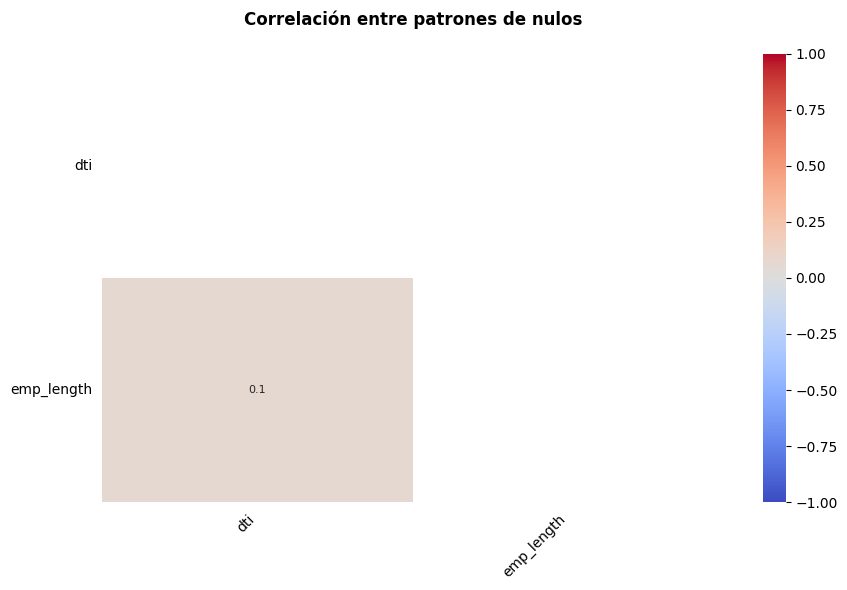

  PRUEBA MCAR 

Variable                % null_default0  % null_default1    p-value Significancia
-----------------------------------------------------------------
loan_amnt                             —                —          —  Sin nulos
int_rate                              —                —          —  Sin nulos
annual_inc                            —                —          —  Sin nulos
dti                               0.03%            0.03%   6.83e-01     NS
fico_range_high                       —                —          —  Sin nulos
emp_length                        5.33%            7.87%   0.00e+00 Muy Alta
purpose                               —                —          —  Sin nulos
home_ownership                        —                —          —  Sin nulos
addr_state                            —                —          —  Sin nulos
verification_status                   —                —          —  Sin nulos


In [ ]:
import missingno as msno

vars_todas = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
              'fico_range_high', 'emp_length',
              'purpose', 'home_ownership', 'addr_state',
              'verification_status', 'default']

df_miss = df_eda[vars_todas].copy()

#Reportar, para cada columna, el número y porcentaje de valores nulos.
nulos      = df_miss.isnull().sum()
porcentaje = (nulos / len(df_miss) * 100).round(4)
dtype_col  = df_miss.dtypes

tabla_nulos = pd.DataFrame({
    'Tipo'       : dtype_col,
    'Nulos'      : nulos,
    'Porcentaje' : porcentaje,
}).sort_values('Porcentaje', ascending=False)

print("  VALORES FALTANTES POR VARIABLE \n")
print(tabla_nulos.to_string())

#Visualizar el patrón de missing values
muestra = df_miss.sample(min(10_000, len(df_miss)), random_state=42)

# 2b. Heatmap de correlación de nulos
fig, ax = plt.subplots(figsize=(9, 6))
msno.heatmap(muestra, ax=ax, fontsize=10, cmap='coolwarm')
ax.set_title('Correlación entre patrones de nulos\n',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


#Analizar valores faltantes
print("  PRUEBA MCAR \n")
print(f"{'Variable':<22} {'% null_default0':>16} {'% null_default1':>16} "
      f"{'p-value':>10} {'Significancia':>6}")
print("-" * 65)

for var in vars_todas:
    if var == 'default':
        continue
    n_nulos = df_miss[var].isnull().sum()
    if n_nulos == 0:
        print(f"{var:<22} {'—':>16} {'—':>16} {'—':>10} {'Sin nulos':>10}")
        continue

    # Crear indicador binario de missing
    indicador = df_miss[var].isnull().astype(int)
    tabla_chi  = pd.crosstab(indicador, df_miss['default'])

    if tabla_chi.shape == (2, 2):
        chi2, pval, _, _ = chi2_contingency(tabla_chi)
        sig = 'Muy Alta' if pval < 0.001 else ('Alta' if pval < 0.01 else
              ('Regular'  if pval < 0.05  else 'NS'))

        # Tasa de nulos por clase
        pct0 = (df_miss[df_miss['default']==0][var].isnull().mean()*100)
        pct1 = (df_miss[df_miss['default']==1][var].isnull().mean()*100)
        print(f"{var:<22} {pct0:>15.2f}% {pct1:>15.2f}% "
              f"{pval:>10.2e} {sig:>6}")
    else:
        print(f"{var:<22} {'—':>16} {'—':>16} {'solo 1 clase':>10}")

#Plan de tratamiento

